# Part 6 — molecule-head prediction: the `balanced_bce` family

Same six objectives as `part_5` (`grid_0000`/`bce`, `grid_0001`/`+contractive`,
`grid_0002`/`+peak_random`, `grid_0003`/`+peak_label_invariant`,
`grid_0004`/`+contractive+peak_label_invariant`,
`grid_0005`/`grid_0004+negw_multilabel_jaccard`) — all six use the identical
`balanced_bce` head loss ([`methodology.md`](../report/methodology.md) §5), so any
difference in classification quality below is attributable to the encoder
representation each regularizer/contrastive term shapes, not to a different
head-loss function (unlike `grid_0006`'s `nnpu`, which is a genuinely different loss
and not comparable this way — out of scope here). `part_4`/`part_7` already
established that `+contractive` genuinely flattens the encoder locally and collapses
the latent cloud — this notebook is where that geometric change gets checked against
actual classification quality, together with the two new chain questions:
does `+contractive` change anything once layered onto `+peak_label_invariant`
(`grid_0003` → `grid_0004`), and does `+negw_multilabel_jaccard` change anything on
top of that (`grid_0004` → `grid_0005`)?

Reuses `part_2`'s fixed `evaluate_head`/`per_class_metrics` (the per-class
`(sample, class)` mask handling — `analysis.autoencoder.heads.metrics`) and its
all-zero-baseline framing for why `average_precision` (macro AUPRC), not
`hamming_loss`/accuracy-shaped metrics, is the number to trust here.

**Scope**: all 5 repetitions on the **test** split (the primary, held-out read,
matching `part_2`'s rigor); repetition 0 additionally evaluated on **train** as well,
to read the generalization gap directly rather than relying on total-loss curves alone
(validation is not needed for this comparison, per this campaign's scope notes). This
notebook's closing notes are, together with `part_5`'s, the intended "final conclusion
for the balanced_bce family."


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import evaluate_head, per_class_metrics, probabilities_from_logits
from msi_autoencoder_wrapper.visualization import resolve_theme


2026-08-28 02:38:53,542 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 02:38:53,548 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 02:38:54,433 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 02:38:54,434 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 02:38:54,436 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 02:38:54,437 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 02:38:54,461 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 02:38:54,672 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 02:38:54,674 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "kidney-architecture-predictive__cfg_529dc0e4494b"
GRID_ID_BY_OBJECTIVE = {
    "bce": "grid_0000",
    "contractive": "grid_0001",
    "peak_random": "grid_0002",
    "peak_label_invariant": "grid_0003",
    "grid4": "grid_0004",
    "grid5": "grid_0005",
}
OBJECTIVE_LABELS = {
    "bce": "bce",
    "contractive": "+contractive",
    "peak_random": "+peak_random",
    "peak_label_invariant": "+peak_label_invariant",
    "grid4": "+contractive+peak_label_invariant",
    "grid5": "+contractive+peak_label_invariant+jaccard",
}

# Curated comparison pairs (not all C(6,2)=15): each single-term objective vs. bce,
# plus the two chain links this notebook adds — matches part_5's PAIRS.
PAIRS = [
    ("bce", "contractive"),
    ("bce", "peak_random"),
    ("bce", "peak_label_invariant"),
    ("peak_label_invariant", "grid4"),
    ("grid4", "grid5"),
    ("bce", "grid4"),
    ("bce", "grid5"),
]

REPETITIONS = range(5)
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256

theme = resolve_theme(None)
theme.apply()


## Environment workaround (same as `part_2`)


In [3]:
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())


## Evaluate every (objective, repetition) on test; repetition 0 also on train


In [4]:
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)


def evaluate_split(model, partitions, split_name: str) -> dict:
    device = next(model.parameters()).device
    dataset = getattr(partitions, split_name)
    logits_batches, target_batches, mask_batches = [], [], []
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for _, spectra, targets, masks in loader:
            outputs = model(spectra.float().to(device))
            logits_batches.append(outputs[f"head_{HEAD_NAME}"].cpu().numpy())
            target_batches.append(targets[TARGET_FIELD].numpy())
            mask_batches.append(masks[TARGET_FIELD].numpy())
    return {
        "logits": np.concatenate(logits_batches, axis=0),
        "targets": np.concatenate(target_batches, axis=0),
        "mask": np.concatenate(mask_batches, axis=0),
        "size": len(dataset),
    }


# All six objectives share one image/binner/annotation-store/dataset context
# (verified in part_5) — only the model weights differ between
# grid_0000/0001/0002/0003/0004/0005 and their repetitions. `load_configuration`
# unconditionally re-resolves the raw imzML reader and annotation index on every
# call (measured ~37-40s), even when nothing about the image actually changed —
# a real cost sink at 30 model loads.
# `models_manager.load_model` swaps only the model architecture/weights (its own
# docstring: "does not require loading its original image") and leaves
# `active_dataset`/context untouched — measured ~0.04s. So: pay the full context
# cost exactly once, then use the lightweight swap for every other model.
first_objective, first_grid_id = next(iter(GRID_ID_BY_OBJECTIVE.items()))
wrapper.load_configuration(model_name=f"{CAMPAIGN_ID}__{first_grid_id}__rep_00")
shared_partitions = wrapper.active_dataset.create_partitions()

results = {}
for objective, grid_id in GRID_ID_BY_OBJECTIVE.items():
    for repetition in REPETITIONS:
        model_name = f"{CAMPAIGN_ID}__{grid_id}__rep_0{repetition}"
        if (objective, repetition) == (first_objective, 0):
            model = wrapper.active_model  # already loaded above
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        results[(objective, repetition, "test")] = evaluate_split(model, shared_partitions, "test")
        if repetition == 0:
            results[(objective, repetition, "train")] = evaluate_split(model, shared_partitions, "train")
        print(f"{objective} rep {repetition}: done")


2026-08-28 02:38:55,419 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 02:38:55,420 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 02:38:55,421 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 02:38:55,422 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 02:38:55,423 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 02:45:05,278 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-28 02:45:05,278 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-28 02:45:05,281 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 02:45:05,286 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


grid5 rep 4: done


In [5]:
# Molecule classes are scored under `unobserved_label_policy: unlabelled`: a class
# can have plenty of *available* (labelled) train pixels while every single one is a
# confirmed negative, so the model received zero positive supervision for it and had
# no way to learn to predict it (see part_2 for the full argument). But "trainable"
# alone is not a fair evaluation scope either: a trainable class with zero positives
# in the split being SCORED is exactly as degenerate (f1/precision/recall trivially
# 0) as an untrainable one. The fair scope is always the intersection -- trainable
# AND scoreable-here -- computed against test ground truth below (shared across every
# objective/repetition, since only the model weights differ).
def collect_targets_and_mask(dataset) -> tuple[np.ndarray, np.ndarray]:
    target_batches, mask_batches = [], []
    for _, _, targets, masks in DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False):
        target_batches.append(targets[TARGET_FIELD].numpy())
        mask_batches.append(masks[TARGET_FIELD].numpy())
    return np.concatenate(target_batches, axis=0), np.concatenate(mask_batches, axis=0)


train_targets_only, train_mask_only = collect_targets_and_mask(shared_partitions.train)
train_positive_count_per_class = (train_targets_only * train_mask_only).sum(axis=0)
train_active_class_mask = train_positive_count_per_class > 0
print(
    f"{int(train_active_class_mask.sum())}/{train_active_class_mask.shape[0]} classes had at least one "
    "positive TRAIN pixel -- only these could plausibly have been learned, by any objective."
)

test_positive_count_per_class = (
    results[(first_objective, 0, "test")]["targets"] * results[(first_objective, 0, "test")]["mask"]
).sum(axis=0)
test_active_class_mask = test_positive_count_per_class > 0
test_fair_mask = train_active_class_mask & test_active_class_mask
print(
    f"train-active ∩ test-active: {int(test_fair_mask.sum())}/{test_fair_mask.shape[0]} classes are both "
    "learnable and have test ground truth to score against"
)

ALL_CLASSES_SCOPE = "all classes (508)"
TRAIN_ACTIVE_SCOPE = "train-active ∩ split-active"
METRIC_GROUPS = {
    "ranking (threshold-free)": ["average_precision", "roc_auc"],
    "macro": ["macro_f1", "macro_precision", "macro_recall"],
    "micro": ["micro_f1", "micro_precision", "micro_recall"],
    "calibration @ 0.5": ["hamming_loss", "hamming_loss_baseline_positive_rate"],
}
scope_column_tuples = [
    (scope_name, group, column)
    for scope_name in (ALL_CLASSES_SCOPE, TRAIN_ACTIVE_SCOPE)
    for group, columns in METRIC_GROUPS.items()
    for column in columns
]

204/508 classes had at least one positive TRAIN pixel -- only these could plausibly have been learned, by any objective.
train-active ∩ test-active: 31/508 classes are both learnable and have test ground truth to score against


## Aggregate metrics — mean/std across repetitions, test split

### Methodology
#### Theoretical
- Compares classification quality across all six `balanced_bce`-family objectives,
  averaged over their 5 repetitions each, to see whether any regularizer/contrastive
  addition changes prediction quality relative to plain `bce`. As with `part_2`, a
  class being trainable (had ≥1 positive train pixel — the same 204/508 classes for
  every objective here, since they all share one train split) does not make it fairly
  scoreable in a given evaluation; every metric below is reported both over the full
  508-class pool and over the fair scope (`train-active ∩ split-active`) side by
  side.

#### Implementation
- For each `(objective, repetition)`, `evaluate_head` is run twice on the test split
  — once with `class_selector = slice(None)`, once with the fair mask
  (`train_active_class_mask & test_active_class_mask`, a single fixed mask here since
  every objective shares the same test ground truth) — then averaged across the 5
  repetitions per objective via `groupby(["objective", "scope"]).mean()`. Results are
  assembled into the same grouped-table layout as `part_2`, now also including
  `macro_precision`/`macro_recall` alongside `macro_f1`.
- The table above only shows the mean across repetitions. The violin+scatter grid
  below it (`visualization.metrics.plot_violin_with_points`, one figure per scope)
  shows the actual 5 raw per-repetition values for every metric — a mean/std pair
  alone cannot reveal that a metric has, say, one outlier repetition or a genuinely
  bimodal spread; the raw points make that visible directly instead of implying a
  smoother distribution than 5 points actually supports.

### Notes
- 204/508 classes are train-active (shared across all six objectives); 31/508 are
  additionally test-active (`train-active ∩ test-active` — the fair scope).
- **All-classes scope**: average_precision is essentially flat across the family,
  0.352-0.364 — see the null check below for whether that flatness survives seed
  noise.
- **Fair scope**: average_precision spreads much more widely, 0.449-0.519 — notably,
  `+peak_label_invariant` (0.519) and `bce` (0.512) sit well above every objective
  that includes `+contractive` (`+contractive` alone 0.458, `grid_0004` 0.449,
  `grid_0005` 0.456). This gap is invisible in the all-classes scope and is examined
  against seed noise in the next section.


In [6]:
aggregate_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for repetition in REPETITIONS:
        result = results[(objective, repetition, "test")]
        for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (TRAIN_ACTIVE_SCOPE, test_fair_mask)):
            metrics = evaluate_head(
                result["logits"][:, class_selector], result["targets"][:, class_selector],
                "multi_label", result["mask"][:, class_selector], THRESHOLD,
            )
            aggregate_rows.append({
                "objective": OBJECTIVE_LABELS[objective], "repetition": repetition,
                "split": "test", "scope": scope_name, **metrics,
            })

aggregate_frame = pd.DataFrame(aggregate_rows)

# Mean across repetitions, grouped the same way as part_2: non-thresholded ranking
# metrics first (the ones actually trusted), then macro/micro/calibration for
# context, with the two class-coverage scopes side by side.
unique_metric_columns = list(dict.fromkeys(column for _, _, column in scope_column_tuples))
aggregate_by_objective_scope = aggregate_frame.groupby(["objective", "scope"])[unique_metric_columns].mean()
grouped_aggregate_frame = pd.DataFrame(
    {
        column_tuple: aggregate_by_objective_scope.xs(column_tuple[0], level="scope")[column_tuple[2]]
        for column_tuple in scope_column_tuples
    }
)
grouped_aggregate_frame.columns = pd.MultiIndex.from_tuples(scope_column_tuples)
grouped_aggregate_frame = grouped_aggregate_frame.reindex(list(OBJECTIVE_LABELS.values()))
grouped_aggregate_frame

all classes (508)            \
                                          ranking (threshold-free)             
                                                 average_precision   roc_auc   
objective                                                                      
bce                                                       0.364260  0.565003   
+contractive                                              0.353019  0.559688   
+peak_random                                              0.358037  0.567305   
+peak_label_invariant                                     0.363741  0.572110   
+contractive+peak_label_invariant                         0.357359  0.563396   
+contractive+peak_label_invariant+jaccard                 0.352058  0.557957   

                                                                     \
                                              macro                   
                                           macro_f1 macro_precision   
objective                                                             
bce                                        0.047808        0.049755   
+contractive                               0.043745        0.040290   
+peak_random                               0.049268        0.050347   
+peak_label_invariant                      0.046680        0.050712   
+contractive+peak_label_invariant          0.044669        0.041606   
+contractive+peak_label_invariant+jaccard  0.043659        0.039744   

                                                                  \
                                                           micro   
                                          macro_recall  micro_f1   
objective                                                          
bce                                           0.087616  0.118053   
+contractive                                  0.086826  0.121633   
+peak_random                                  0.091859  0.122736   
+peak_label_invariant                         0.088307  0.115111   
+contractive+peak_label_invariant             0.087730  0.125165   
+contractive+peak_label_invariant+jaccard     0.086789  0.124330   

                                                                        \
                                                                         
                                          micro_precision micro_recall   
objective                                                                
bce                                              0.069796     0.382828   
+contractive                                     0.072354     0.382219   
+peak_random                                     0.072543     0.398777   
+peak_label_invariant                            0.068054     0.373804   
+contractive+peak_label_invariant                0.074523     0.391120   
+contractive+peak_label_invariant+jaccard        0.074062     0.387551   

                                                             \
                                          calibration @ 0.5   
                                               hamming_loss   
objective                                                     
bce                                                0.328477   
+contractive                                       0.316720   
+peak_random                                       0.327895   
+peak_label_invariant                              0.330399   
+contractive+peak_label_invariant                  0.313666   
+contractive+peak_label_invariant+jaccard          0.313336   

                                                                               \
                                                                                
                                          hamming_loss_baseline_positive_rate   
objective                                                                       
bce                                                                  0.057393   
+contractive                                                         0.057393  

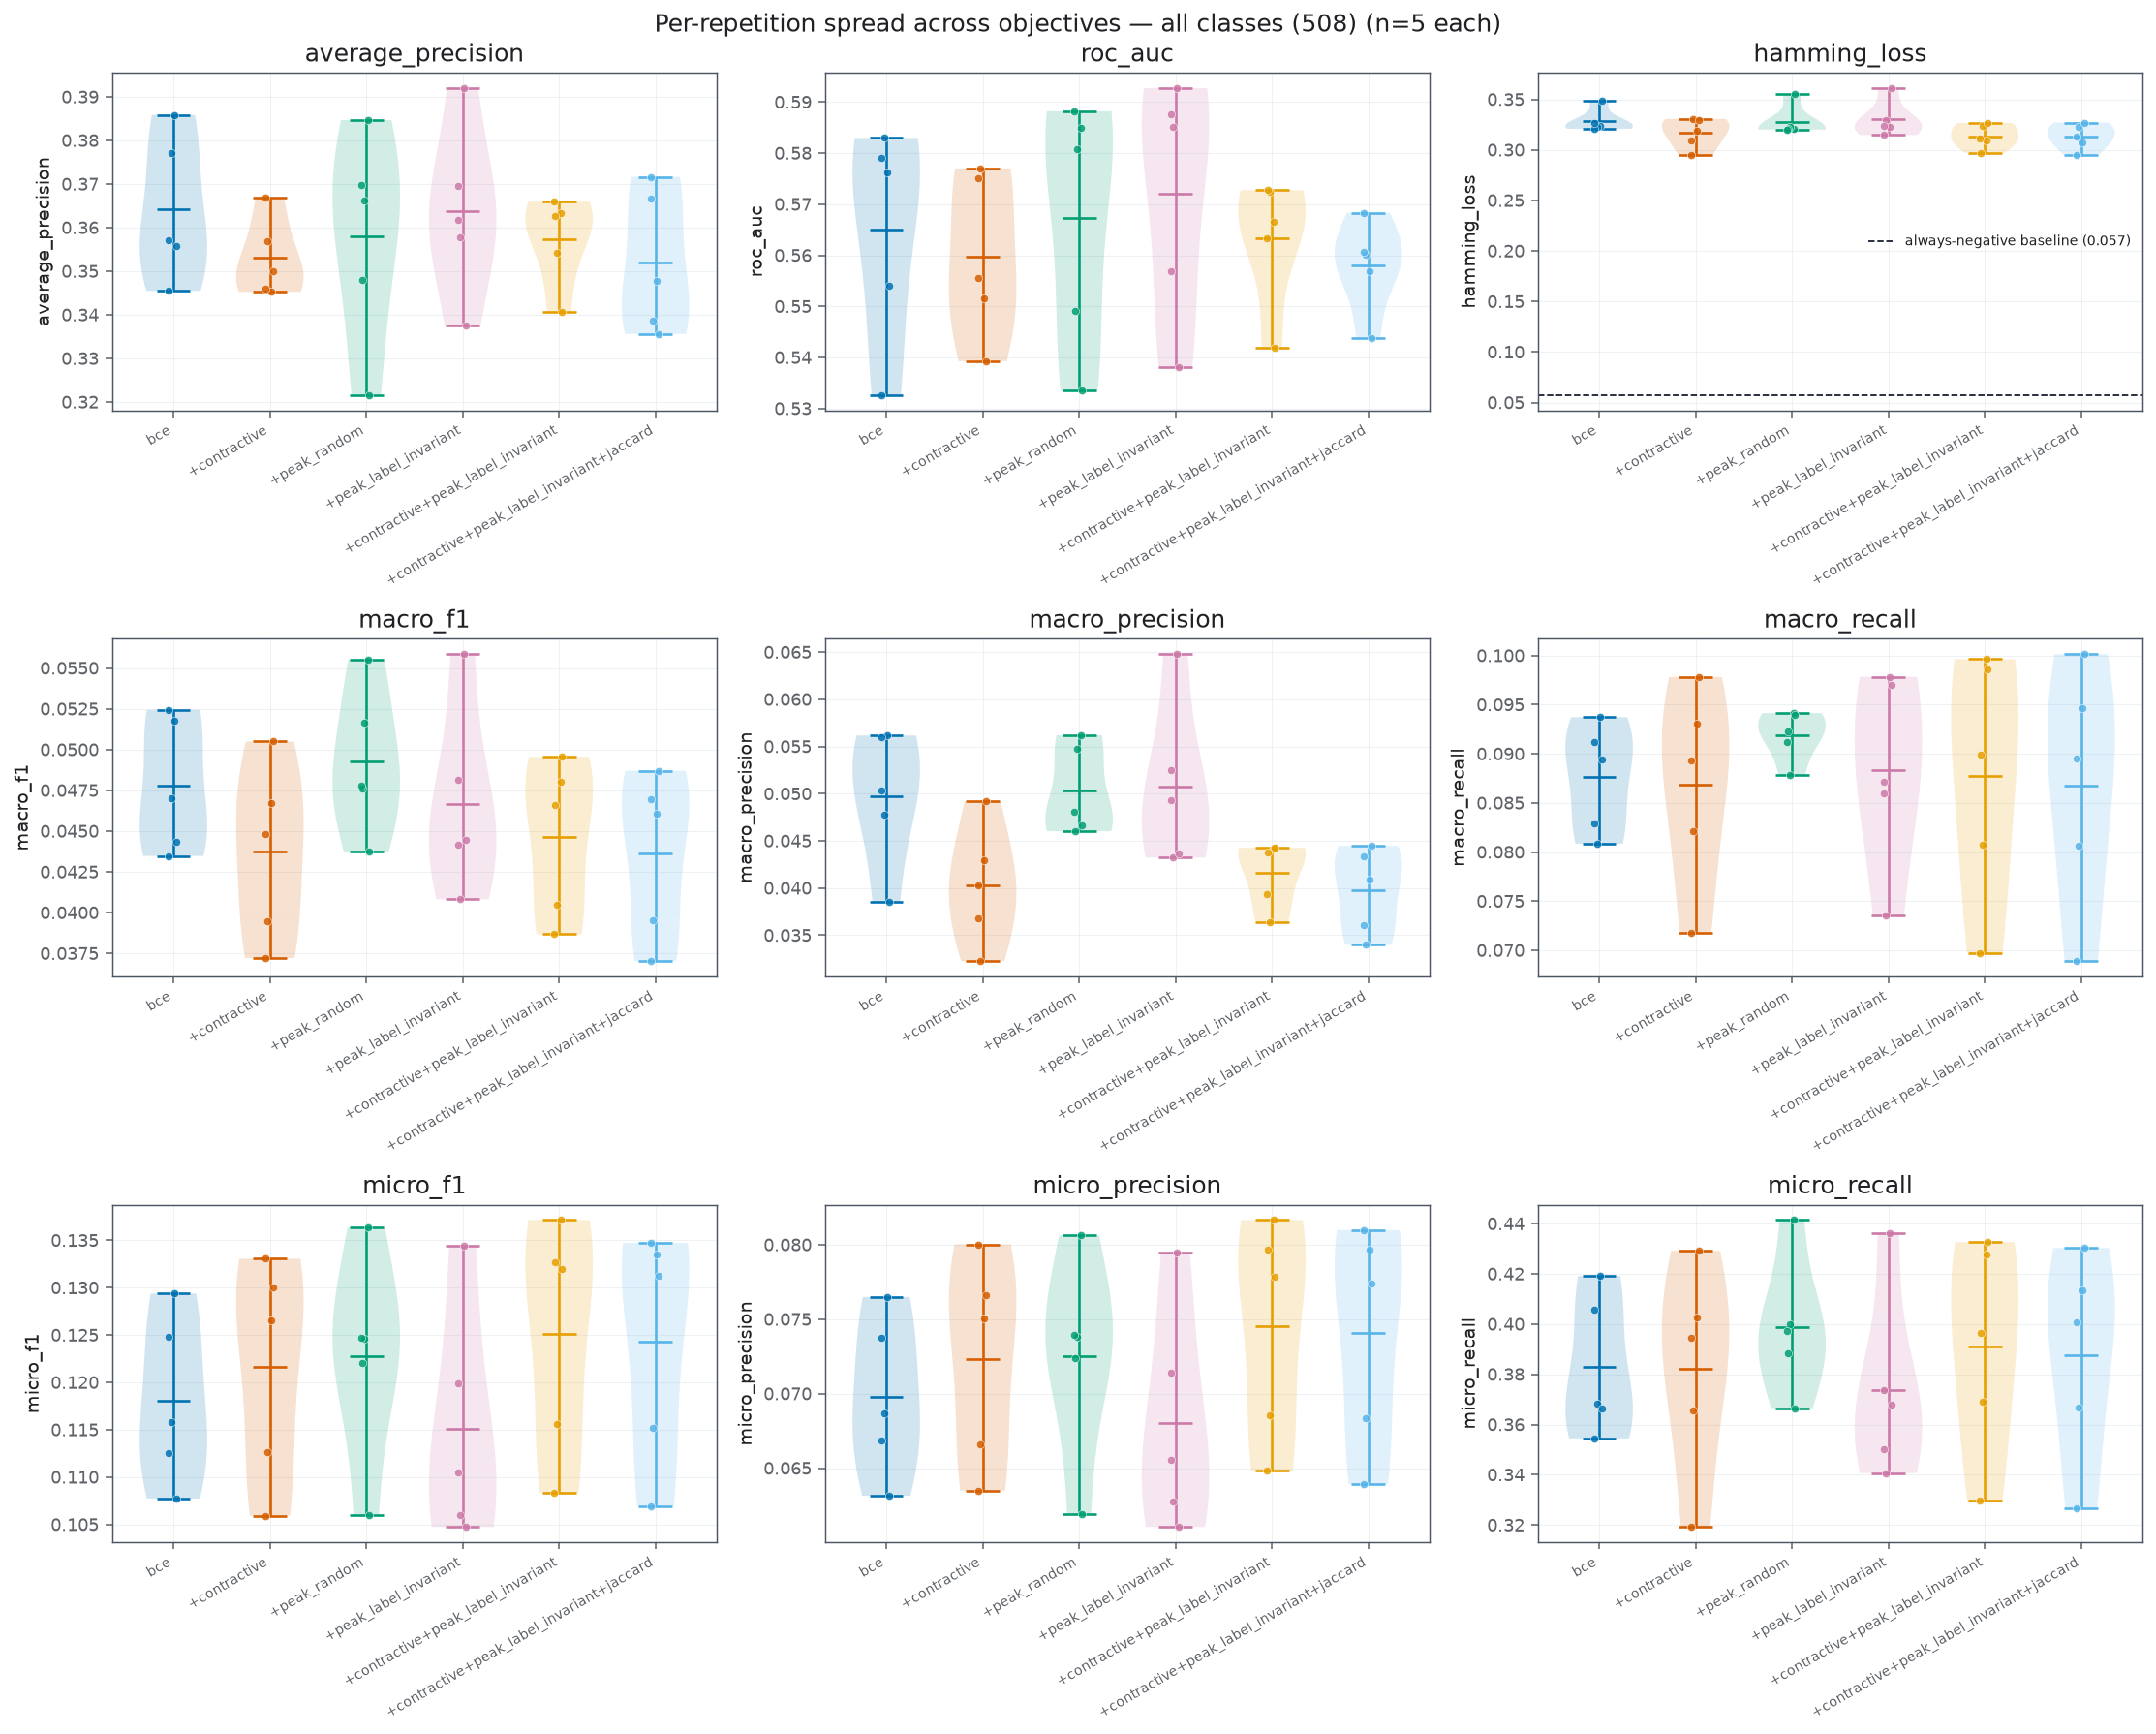

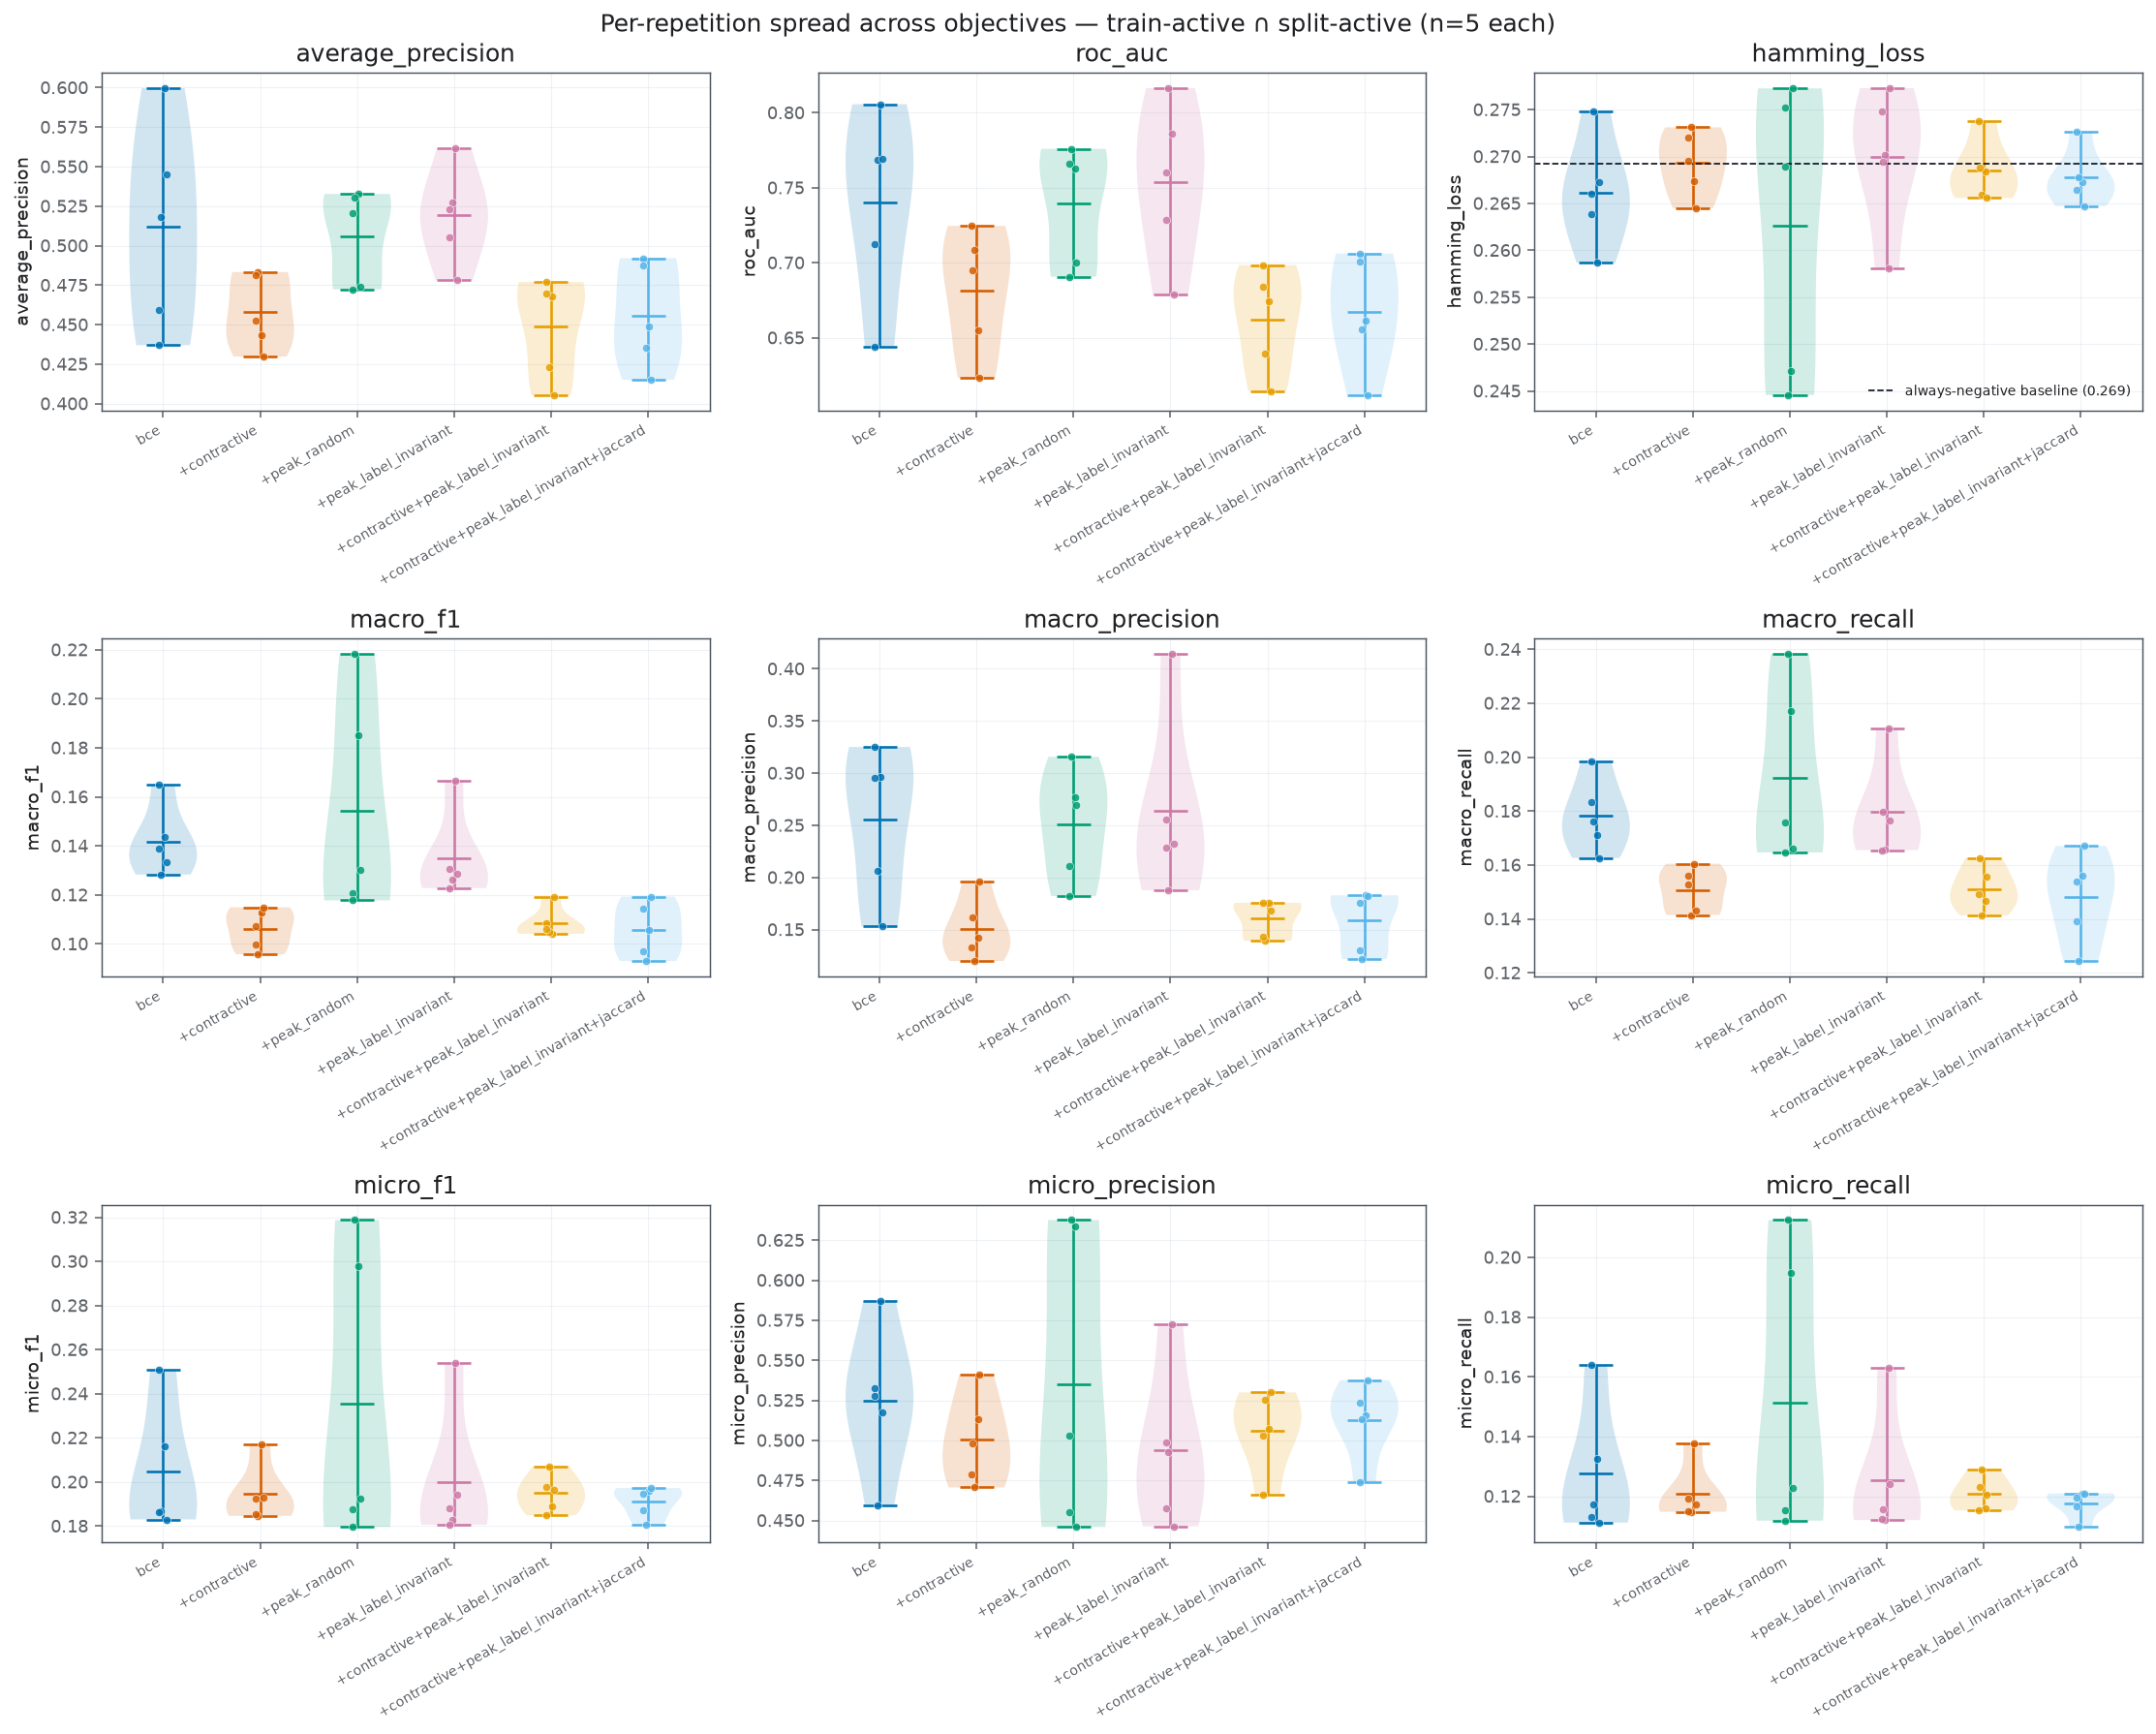

In [7]:
import matplotlib.pyplot as plt

from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

# Layout: row 0 = ranking metrics + calibration (unrelated to each other, one each);
# rows 1-2 = macro vs. micro, column-aligned by metric (f1/precision/recall) so
# macro and micro versions of the same metric sit directly above/below each other.
# Each panel keeps its own y-scale (macro and micro operate on very different
# numeric ranges here -- forcing a shared scale clips one of them off-screen).
panel_layout = [
    ["average_precision", "roc_auc", "hamming_loss"],
    ["macro_f1", "macro_precision", "macro_recall"],
    ["micro_f1", "micro_precision", "micro_recall"],
]
objectives = list(OBJECTIVE_LABELS.values())

for scope_name in (ALL_CLASSES_SCOPE, TRAIN_ACTIVE_SCOPE):
    scoped_frame = aggregate_frame[aggregate_frame["scope"] == scope_name]
    hamming_baseline = scoped_frame["hamming_loss_baseline_positive_rate"].iloc[0]
    figure, axes = plt.subplots(3, 3, figsize=(16.0, 13.0), dpi=theme.figure_dpi)
    for row, metric_row in enumerate(panel_layout):
        for column, metric_name in enumerate(metric_row):
            axis = axes[row, column]
            for objective_index, objective in enumerate(objectives):
                values = scoped_frame.loc[scoped_frame["objective"] == objective, metric_name].to_numpy()
                plot_violin_with_points(
                    values, position=objective_index, ax=axis, width=0.7,
                    color=theme.color_for_model(objective, objective_index),
                )
            if metric_name == "hamming_loss":
                axis.axhline(hamming_baseline, color=theme.baseline_color, linestyle=theme.baseline_line_style,
                             linewidth=theme.reference_line_width, label=f"always-negative baseline ({hamming_baseline:.3f})")
                axis.legend(fontsize=7, frameon=theme.legend_frame)
            axis.set_xticks(range(len(objectives)))
            axis.set_xticklabels(objectives, rotation=30, ha="right", fontsize=7)
            axis.set(ylabel=metric_name, title=metric_name)
            axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    figure.suptitle(f"Per-repetition spread across objectives — {scope_name} (n=5 each)", fontsize=13)
    figure.tight_layout()

In [8]:
aggregate_frame.sort_values(["objective", "scope", "repetition"]).reset_index(drop=True)

,objective,repetition,split,scope,micro_f1,macro_f1,macro_precision,macro_recall,micro_precision,micro_recall,hamming_loss,hamming_loss_baseline_positive_rate,average_precision,roc_auc
0,+contractive,0,test,all classes (508),0.126515,0.046706,0.042998,0.093102,0.075051,0.402570,0.319040,0.057393,0.345249,0.551495
1,+contractive,1,test,all classes (508),0.112651,0.039501,0.032274,0.082170,0.066581,0.365671,0.330630,0.057393,0.356891,0.577021
2,+contractive,2,test,all classes (508),0.133058,0.044818,0.040237,0.089301,0.080024,0.394513,0.295055,0.057393,0.366928,0.575094
3,+contractive,3,test,all classes (508),0.105925,0.037207,0.036774,0.071746,0.063499,0.319198,0.309261,0.057393,0.346076,0.555554
4,+contractive,4,test,all classes (508),0.130017,0.050494,0.049169,0.097812,0.076615,0.429144,0.329613,0.057393,0.349949,0.539273
5,+contractive,0,test,train-active ∩ split-active,0.217135,0.112951,0.142274,0.160442,0.513037,0.137709,0.267358,0.269242,0.443366,0.654743
6,+contractive,1,test,train-active ∩ split-active,0.184582,0.095774,0.119775,0.141425,0.470581,0.114807,0.273107,0.269242,0.483296,0.708572
7,+contractive,2,test,train-active ∩ split-active,0.192499,0.099704,0.161666,0.152799,0.498073,0.119304,0.269491,0.269242,0.452386,0.695172
8,+contractive,3,test,train-active ∩ split-active,0.185459,0.107354,0.132936,0.155994,0.478563,0.115016,0.272017,0.269242,0.481134,0.724542
9,+contractive,4,test,train-active ∩ split-active,0.192844,0.114925,0.196140,0.143225,0.540912,0.117339,0.264463,0.269242,0.429782,0.623355


## Is the between-objective difference bigger than seed noise?

### Methodology
#### Theoretical
- Same check as `part_5` Stage 1b and `part_7`'s corrected geometry comparison,
  applied here from the start rather than retrofitted: any between-objective
  difference is only worth interpreting if it exceeds the spread already present
  between two repetitions of the *same* objective (pure seed noise). Checked
  separately in both the all-classes and fair scopes, since the previous section
  shows they can disagree.

#### Implementation
- Null distribution: within-objective `|rep_i - rep_j|` on `average_precision` (the
  metric `part_2` established as the one to trust for this head), all
  `C(5,2)=10` repetition pairs per objective. Signal: `|mean(objective_a) -
  mean(objective_b)|` for each of the 7 curated `PAIRS`. `signal_over_larger_null =
  signal / max(null_mean(a), null_mean(b))` — a ratio above 1 means the observed
  between-objective gap exceeds the larger of the two objectives' own seed-noise
  spread.

### Notes
- **All-classes scope**: every one of the 7 comparisons stays below the null
  (signal/null 0.02-0.60) — no detectable between-objective effect at this scope,
  matching the "flat" reading in the previous section.
- **Fair scope — this reverses that conclusion for one comparison.**
  `+peak_label_invariant → +contractive+peak_label_invariant` (`grid_0004`) reaches
  **signal/null = 1.86** (between-objective gap 0.0705, vs. within-objective null
  means of 0.038/0.038) — the only comparison in either scope to clear the null. The
  direction is unambiguous from the aggregate table above: `+peak_label_invariant`
  (fair-scope AP 0.519) outperforms `grid_0004` (0.449) — adding `+contractive` on
  top of `+peak_label_invariant` measurably *hurts* classification once scored on the
  classes that are actually learnable and present in test, even though the same
  comparison looks like noise (0.26) in the all-classes scope. Every other fair-scope
  comparison stays below its null (0.07-0.77), including `grid_0004 → grid_0005`
  (`+jaccard`, 0.18) and `bce` vs. every single-term objective (0.07-0.65) — so this
  is specifically a `+contractive` effect, not a general fair-scope inflation of
  every comparison.


In [9]:
from itertools import combinations

primary_metric = "average_precision"
comparison_rows = []
for scope_name in (ALL_CLASSES_SCOPE, TRAIN_ACTIVE_SCOPE):
    scoped_frame = aggregate_frame[aggregate_frame["scope"] == scope_name]
    null_rows = []
    for objective in GRID_ID_BY_OBJECTIVE:
        values = scoped_frame.loc[scoped_frame["objective"] == OBJECTIVE_LABELS[objective], primary_metric].to_numpy()
        reps = scoped_frame.loc[scoped_frame["objective"] == OBJECTIVE_LABELS[objective], "repetition"].to_numpy()
        for (i, value_a), (j, value_b) in combinations(zip(reps, values), 2):
            null_rows.append({"objective": OBJECTIVE_LABELS[objective], "rep_pair": f"{i}-{j}", "abs_diff": abs(value_a - value_b)})

    null_frame = pd.DataFrame(null_rows)
    null_summary = null_frame.groupby("objective")["abs_diff"].agg(["mean", "std", "min", "max"])
    objective_means = scoped_frame.groupby("objective")[primary_metric].mean()

    print(f"=== scope: {scope_name} ===")
    print(f"within-objective |rep_i - rep_j| null ({primary_metric}):")
    print(null_summary)
    print()

    for left_key, right_key in PAIRS:
        left_label, right_label = OBJECTIVE_LABELS[left_key], OBJECTIVE_LABELS[right_key]
        pair_label = f"{left_label} vs {right_label}"
        between = abs(objective_means[left_label] - objective_means[right_label])
        larger_null = max(null_summary.loc[left_label, "mean"], null_summary.loc[right_label, "mean"])
        comparison_rows.append({
            "scope": scope_name, "pair": pair_label,
            "between_mean": between, "larger_null_mean": larger_null,
            "signal_over_larger_null": between / larger_null,
        })
        print(f"between-objective |mean({left_label}) - mean({right_label})|: {between:.4f} (signal/null = {between / larger_null:.2f})")
    print()

comparison_frame = pd.DataFrame(comparison_rows)
comparison_frame

=== scope: all classes (508) ===
within-objective |rep_i - rep_j| null (average_precision):
                                               mean       std       min  \
objective                                                                 
+contractive                               0.010835  0.007137  0.000827   
+contractive+peak_label_invariant          0.011901  0.008841  0.000563   
+contractive+peak_label_invariant+jaccard  0.020059  0.012185  0.002973   
+peak_label_invariant                      0.024145  0.014800  0.003885   
+peak_random                               0.029595  0.018113  0.003700   
bce                                        0.020436  0.012379  0.001260   

                                                max  
objective                                            
+contractive                               0.021679  
+contractive+peak_label_invariant          0.025244  
+contractive+peak_label_invariant+jaccard  0.036050  
+peak_label_invariant                

,scope,pair,between_mean,larger_null_mean,signal_over_larger_null
0,all classes (508),bce vs +contractive,0.011241,0.020436,0.550050
1,all classes (508),bce vs +peak_random,0.006222,0.029595,0.210257
2,all classes (508),bce vs +peak_label_invariant,0.000519,0.024145,0.021484
3,all classes (508),+peak_label_invariant vs +contractive+peak_lab...,0.006381,0.024145,0.264292
4,all classes (508),+contractive+peak_label_invariant vs +contract...,0.005301,0.020059,0.264278
5,all classes (508),bce vs +contractive+peak_label_invariant,0.006900,0.020436,0.337643
6,all classes (508),bce vs +contractive+peak_label_invariant+jaccard,0.012201,0.020436,0.597050
7,train-active ∩ split-active,bce vs +contractive,0.053747,0.082203,0.653827
8,train-active ∩ split-active,bce vs +peak_random,0.005704,0.082203,0.069390
9,train-active ∩ split-active,bce vs +peak_label_invariant,0.007331,0.082203,0.089177


## Train vs. test — repetition 0

### Methodology
#### Theoretical
- Same metrics computed on the pixels each model actually trained on, for a direct
  generalization-gap read per objective (analogous to `part_1`'s train/validation
  Masserstein gap, but for the classification head) — again in both the all-classes
  and fair scopes, since train's own fair scope is trivially the full train-active
  set (204 classes) while test's fair scope is the much smaller 31-class
  intersection.

#### Implementation
- For each objective, `evaluate_head` is run on `train` and `test` (repetition 0
  only), in both scopes, producing a `(objective, split, scope)`-indexed grouped
  table with the same metric-family layout as the aggregate table above.

### Notes


In [10]:
gap_rows = []
for objective in GRID_ID_BY_OBJECTIVE:
    for split_name in ("train", "test"):
        result = results[(objective, 0, split_name)]
        positive_count_per_class = (result["targets"] * result["mask"]).sum(axis=0)
        split_active_mask = positive_count_per_class > 0
        fair_mask = train_active_class_mask & split_active_mask
        for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (TRAIN_ACTIVE_SCOPE, fair_mask)):
            metrics = evaluate_head(
                result["logits"][:, class_selector], result["targets"][:, class_selector],
                "multi_label", result["mask"][:, class_selector], THRESHOLD,
            )
            gap_rows.append({
                "objective": OBJECTIVE_LABELS[objective], "split": split_name,
                "scope": scope_name, **metrics,
            })

gap_frame = pd.DataFrame(gap_rows)
gap_by_objective_split_scope = gap_frame.set_index(["objective", "split", "scope"])
grouped_gap_frame = pd.DataFrame(
    {
        column_tuple: gap_by_objective_split_scope.xs(column_tuple[0], level="scope")[column_tuple[2]]
        for column_tuple in scope_column_tuples
    }
)
grouped_gap_frame.columns = pd.MultiIndex.from_tuples(scope_column_tuples)
grouped_gap_frame = grouped_gap_frame.reindex(
    pd.MultiIndex.from_product([list(OBJECTIVE_LABELS.values()), ["train", "test"]], names=["objective", "split"])
)
grouped_gap_frame

all classes (508)  \
                                                ranking (threshold-free)   
                                                       average_precision   
objective                                 split                            
bce                                       train                 0.613690   
                                          test                  0.385860   
+contractive                              train                 0.525394   
                                          test                  0.345249   
+peak_random                              train                 0.616147   
                                          test                  0.384673   
+peak_label_invariant                     train                 0.626786   
                                          test                  0.391997   
+contractive+peak_label_invariant         train                 0.526347   
                                          test                  0.363243   
+contractive+peak_label_invariant+jaccard train                 0.519073   
                                          test                  0.347700   

                                                                     \
                                                              macro   
                                                  roc_auc  macro_f1   
objective                                 split                       
bce                                       train  0.979513  0.232623   
                                          test   0.576276  0.051750   
+contractive                              train  0.964472  0.216587   
                                          test   0.551495  0.046706   
+peak_random                              train  0.979492  0.231223   
                                          test   0.584966  0.055527   
+peak_label_invariant                     train  0.979712  0.233808   
                                          test   0.592725  0.055857   
+contractive+peak_label_invariant         train  0.962481  0.216022   
                                          test   0.566493  0.048052   
+contractive+peak_label_invariant+jaccard train  0.960893  0.215343   
                                          test   0.556952  0.046047   

                                                                              \
                                                                               
                                                macro_precision macro_recall   
objective                                 split                                
bce                                       train        0.200077     0.318893   
                                          test         0.056162     0.093723   
+contractive                              train        0.186966     0.296082   
                                          test         0.042998     0.093102   
+peak_random                              train        0.199343     0.318323   
                                          test         0.056189     0.094138   
+peak_label_invariant                     train        0.202729     0.316466   
                                          test         0.064786     0.097839   
+contractive+peak_label_invariant         train        0.188399     0.292985   
                                          test         0.044230     0.099628   
+contractive+peak_label_invariant+jaccard train        0.186655     0.293991   
                                          test         0.040852     0.094645   

                                                                           \
                                                    micro                   
                                                 micro_f1 micro_precision   
objective                                 split                             
bce                                       train  0.208419        0.116507   
                                   

## Per-class detail, test split, repetition 0

### Methodology
#### Theoretical
- Complements the aggregate/null-check sections with a class-by-class read: for each
  pair in `PAIRS`, the per-class AUPRC difference (`objective_a - objective_b`)
  across classes both objectives actually have test positives for, summarized via
  `.describe()` (mean, std, quartiles).

#### Implementation
- `per_class_metrics` computed per objective (rep 0, test split), filtered to
  `positive_samples > 0` (same convention as `part_2`: AUPRC is undefined, not zero,
  for a class with no test positives). Joined into one `comparison` frame indexed by
  `class_index`, then `comparison[f"{left}_minus_{right}"] = comparison[left] -
  comparison[right]` for each curated pair.

### Notes
- `peak_label_invariant_minus_grid4` mean 0.029 (small, `+peak_label_invariant`
  slightly ahead) but std 0.289 — an order of magnitude larger than the mean, i.e.
  individually noisy at the per-class level even though the *aggregate* fair-scope
  comparison above clears the seed-noise null. The two readings are not
  contradictory: a consistent-but-small aggregate shift can still look noisy
  class-by-class when the per-class sample sizes are small.
- `grid4_minus_grid5` mean 0.016, std 0.063 — noise-dominated at the per-class level
  too, consistent with that comparison also failing the null check above (0.18).


In [11]:
class_metrics_by_objective = {}
for objective in GRID_ID_BY_OBJECTIVE:
    result = results[(objective, 0, "test")]
    probabilities = probabilities_from_logits(result["logits"], "multi_label")
    frame = pd.DataFrame(per_class_metrics(probabilities, result["targets"], THRESHOLD, result["mask"]))
    class_metrics_by_objective[objective] = frame[frame["positive_samples"] > 0].copy()
    print(f"{objective}: {len(class_metrics_by_objective[objective])} classes scored")


bce: 113 classes scored


contractive: 113 classes scored


peak_random: 113 classes scored


peak_label_invariant: 113 classes scored


grid4: 113 classes scored


grid5: 113 classes scored


In [12]:
comparison = pd.DataFrame({
    objective: class_metrics_by_objective[objective].set_index("class_index")["average_precision"]
    for objective in GRID_ID_BY_OBJECTIVE
}).dropna(how="all")
for left_key, right_key in PAIRS:
    comparison[f"{left_key}_minus_{right_key}"] = comparison[left_key] - comparison[right_key]
comparison.describe()


,bce,contractive,peak_random,peak_label_invariant,grid4,grid5,bce_minus_contractive,bce_minus_peak_random,bce_minus_peak_label_invariant,peak_label_invariant_minus_grid4,grid4_minus_grid5,bce_minus_grid4,bce_minus_grid5
count,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000,113.000000
mean,0.385860,0.345249,0.384673,0.391997,0.363243,0.347700,0.040610,0.001187,-0.006137,0.028754,0.015543,0.022617,0.038160
std,0.297384,0.255279,0.310012,0.300883,0.264936,0.253740,0.286505,0.172261,0.150770,0.288827,0.063103,0.302590,0.296855
min,0.000452,0.000402,0.000503,0.000506,0.000398,0.000415,-0.662684,-0.604577,-0.484339,-0.697690,-0.099612,-0.716942,-0.696440
25%,0.152974,0.179471,0.129175,0.146148,0.198149,0.186436,-0.072195,-0.049214,-0.025320,-0.154235,-0.003520,-0.128412,-0.122341
50%,0.323596,0.285278,0.285154,0.324141,0.291521,0.288927,0.005587,0.004689,0.000993,0.000108,0.000649,0.001956,0.005454
75%,0.608920,0.457532,0.598308,0.636234,0.492453,0.488962,0.196259,0.072742,0.043494,0.147169,0.019379,0.198195,0.218468
max,0.999912,0.981925,0.995477,0.993657,0.998438,0.996427,0.769026,0.535481,0.494058,0.763162,0.446612,0.832058,0.830147


## Notes for the next pass

**Headline, revised after the fair-scope (`train-active ∩ split-active`) check was
added: classification quality is flat across the family in the all-508-class pool,
but `+contractive` measurably hurts classification once scored fairly.** Six of the
seven curated comparisons fail the seed-noise null in both scopes; the exception is
`+peak_label_invariant → +contractive+peak_label_invariant` (`grid_0004`), which
clears the null specifically in the fair scope (signal/null 1.86, `+contractive`
pulling fair-scope AP down from 0.519 to 0.449) while looking like noise in the
all-classes pool (0.26). See the null-check section above for the full comparison
table.

### Result (all 5 repetitions, test AUPRC — all-classes scope, null-checked)

| objective | mean AUPRC | std | vs. predecessor | signal/null |
|---|---|---|---|---|
| `bce` | 0.3643 | 0.0167 | — | — |
| `+contractive` | 0.3530 | 0.0090 | vs. `bce`: 0.0112 | 0.55 (no) |
| `+peak_random` | 0.3580 | 0.0242 | vs. `bce`: 0.0062 | 0.21 (no) |
| `+peak_label_invariant` | **0.3637** | 0.0198 | vs. `bce`: 0.0005 | 0.02 (no) |
| `+contractive+peak_label_invariant` (`grid_0004`) | 0.3574 | 0.0103 | vs. `+peak_label_invariant`: 0.0064 | 0.26 (no) |
| `+contractive+peak_label_invariant+jaccard` (`grid_0005`) | 0.3521 | 0.0164 | vs. `grid_0004`: 0.0053 | 0.26 (no) |

### Result (fair scope, `train-active ∩ test-active`, 31/508 classes)

| objective | mean AUPRC | vs. predecessor | signal/null |
|---|---|---|---|
| `bce` | 0.5117 | — | — |
| `+contractive` | 0.4580 | vs. `bce`: 0.0537 | 0.65 (no) |
| `+peak_random` | 0.5060 | vs. `bce`: 0.0057 | 0.07 (no) |
| `+peak_label_invariant` | **0.5191** | vs. `bce`: 0.0073 | 0.09 (no) |
| `+contractive+peak_label_invariant` (`grid_0004`) | 0.4486 | vs. `+peak_label_invariant`: **0.0705** | **1.86 (yes)** |
| `+contractive+peak_label_invariant+jaccard` (`grid_0005`) | 0.4559 | vs. `grid_0004`: 0.0073 | 0.18 (no) |

- **The train-AUPRC pattern from the 4-objective pass reproduces cleanly and
  strengthens the earlier "lead"** (all-classes scope, repetition 0): `+contractive`
  alone train AUPRC 0.525; `grid_0004` (`+contractive` layered onto
  `+peak_label_invariant`) 0.526 — essentially identical to plain `+contractive`'s
  train fit, *not* to `+peak_label_invariant`'s own train fit (0.627). Whatever
  `+contractive` does to training-set fit, it reproduces almost exactly when combined
  with `+peak_label_invariant`, independent of that term. `grid_0005`'s train AUPRC
  (0.519) continues the same level. Still single-repetition, not null-checked on its
  own, but now corroborated by the fair-scope test-set null check above finding a
  real `+contractive` effect too.

**Combined with `part_5`**: reconstruction and classification now point the *same*
direction for `+contractive`, not opposite directions as first thought. Adding
`+contractive` to `+peak_label_invariant` measurably hurts reconstruction (`part_5`,
signal/null 1.12) *and* measurably hurts fair-scope classification (this notebook,
signal/null 1.86) — the all-classes-scope reading of "classification untouched" was
an artifact of diluting the comparison with ~477 classes the model never had a
realistic chance to score well on either way. `+contractive`'s cost is not confined
to reconstruction detail; it also degrades the class-discriminative signal on the
classes that actually matter for this head — worth checking directly against
`part_7`'s dimension-usage/RSA numbers for the same explanation at the
representation-geometry level.

**Provisional balanced_bce-family conclusion for classification**: `bce` and
`+peak_label_invariant` alone are indistinguishable from each other and are the
strongest performers in the fair scope; `+contractive` (alone or layered onto
`+peak_label_invariant`) is the one objective with a real, null-surviving
classification cost. Combined with `part_5`'s reconstruction verdict
(`+peak_label_invariant` alone is best; `+contractive` on top is a real regression
there too), the balanced_bce-family recommendation is `grid_0003`
(`+peak_label_invariant` alone) over `grid_0004`/`grid_0005` — now supported by both
reconstruction *and* fair-scope classification evidence, not reconstruction alone.
